<a href="https://colab.research.google.com/github/bimireddysanjana/BillsOnChain/blob/main/Recommendation_System_BOC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recommendation System

This notebook extracts data from the PostgreSQL `boc.backup` dump and builds a recommendation engine using Hybrid Collaborative Filtering (SVD, KNN, and Category Affinity).

In [19]:
import json
import os
import pandas as pd
import numpy as np
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import re

## 1. Parse the Database Dump
Extract the `bill_extraction` and `bill` tables from the postgres dump into a raw dataset.

In [20]:
# Robust path finding to support Windows and WSL/Linux environments
possible_paths = [
    "boc.backup",  # If running directly in the BOC folder
    r"/content/boc.backup",  # Absolute Windows path
    "/mnt/c/Users/sanjanab/Desktop/BOC/boc.backup"  # Absolute WSL path
]

DUMP_PATH = None
for path in possible_paths:
    if os.path.exists(path):
        DUMP_PATH = path
        break

if DUMP_PATH is None:
    raise FileNotFoundError(f"Could not find boc.backup! Current working directory is: {os.getcwd()}")

OUTPUT_DATASET = "dataset_notebook.json"
if not os.path.exists(OUTPUT_DATASET) and DUMP_PATH.startswith("/mnt/"):
    # Fallback output path for WSL to ensure it saves in the right Windows folder
    OUTPUT_DATASET = "/mnt/c/Users/sanjanab/Desktop/BOC/dataset_notebook.json"

def parse_dump():
    bills = {}
    transactions = []
    current_table = None

    print(f"Parsing dump from: {DUMP_PATH}")
    with open(DUMP_PATH, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            if line.startswith("COPY public.bill ("):
                current_table = "bill"
                col_str = line.split("(")[1].split(")")[0]
                bill_cols = [c.strip().strip('"') for c in col_str.split(',')]
                continue
            elif line.startswith("COPY public.bill_extraction ("):
                current_table = "bill_extraction"
                col_str = line.split("(")[1].split(")")[0]
                extraction_cols = [c.strip().strip('"') for c in col_str.split(',')]
                continue
            elif line.startswith(r"\."):
                current_table = None
                continue

            if current_table == "bill":
                parts = line.strip('\n').split('\t')
                if len(parts) == len(bill_cols):
                    row = dict(zip(bill_cols, parts))
                    bills[row['id']] = row['userId']
            elif current_table == "bill_extraction":
                parts = line.strip('\n').split('\t')
                if len(parts) == len(extraction_cols):
                    row = dict(zip(extraction_cols, parts))
                    bill_id = row['billId']
                    user_id = bills.get(bill_id)
                    if user_id:
                        line_items_str = row['lineItems']
                        line_items = []
                        if line_items_str and line_items_str != r'\N':
                            try:
                                clean_json = line_items_str.replace(r'\\', '\\')
                                line_items = json.loads(clean_json)
                            except:
                                pass

                        transactions.append({
                            'userId': user_id,
                            'billId': bill_id,
                            'merchantName': row['merchantName'],
                            'category': row['category'],
                            'lineItems': line_items
                        })

    print(f"Extracted {len(bills)} bills and {len(transactions)} transactions.")
    with open(OUTPUT_DATASET, 'w', encoding='utf-8') as f:
        json.dump(transactions, f, indent=2)
    print(f"Dataset saved to: {OUTPUT_DATASET}")
    return transactions

transactions = parse_dump()

Parsing dump from: boc.backup
Extracted 70417 bills and 61763 transactions.
Dataset saved to: dataset_notebook.json


## 2. Data Preprocessing & Train/Test Split
Clean the line items, convert to a DataFrame, and split into train and test sets for evaluation.

In [21]:
def clean_item_name(item):
    if not isinstance(item, str): return ""
    item = item.lower().strip()
    item = re.sub(r'[^a-z0-9 ]+', ' ', item)
    item = re.sub(r'\s+', ' ', item).strip()
    return item

records = []
for txn in transactions:
    uid = txn['userId']
    cat = txn['category']
    for raw_item in txn.get('lineItems', []):
        item = clean_item_name(raw_item)
        if len(item) > 2 and item != "none":
            records.append({
                'userId': uid,
                'item': item,
                'category': cat
            })

df = pd.DataFrame(records)
print(f"Total line items: {len(df)}")

# Filter rare items to reduce noise
item_counts = df['item'].value_counts()
popular_items = item_counts[item_counts >= 3].index
df = df[df['item'].isin(popular_items)]
print(f"Line items after filtering rare items: {len(df)}")

# SPLIT DATA INTO TRAIN AND TEST
# For users with at least 5 purchases, hide 20% of their items for testing.
user_counts = df['userId'].value_counts()
valid_users = user_counts[user_counts >= 5].index
df_valid = df[df['userId'].isin(valid_users)]
df_other = df[~df['userId'].isin(valid_users)]

train_list = []
test_list = []
for uid, group in df_valid.groupby('userId'):
    train, test = train_test_split(group, test_size=0.2, random_state=42)
    train_list.append(train)
    test_list.append(test)

train_df = pd.concat(train_list + [df_other])
test_df = pd.concat(test_list)

print(f"Training Set Size: {len(train_df)}")
print(f"Testing Set Size: {len(test_df)}")

Total line items: 127186
Line items after filtering rare items: 89865
Training Set Size: 72202
Testing Set Size: 17663


## 3. Recommendation Engine Class
Build the models and the logic to combine them.

In [22]:
class RecommendationEngine:
    def __init__(self, df):
        self.df = df
        print("Building matrices...")
        self.user_item_counts = df.groupby(['userId', 'item']).size().reset_index(name='count')
        self.interaction_matrix = self.user_item_counts.pivot(index='userId', columns='item', values='count').fillna(0)
        self.users = list(self.interaction_matrix.index)
        self.items = list(self.interaction_matrix.columns)

        user_cat = df.groupby(['userId', 'category']).size().reset_index(name='count')
        self.user_category_affinity = user_cat.pivot(index='userId', columns='category', values='count').fillna(0)

        self.item_category = df.groupby(['item', 'category']).size().reset_index(name='count')
        self.item_category = self.item_category.sort_values('count', ascending=False).drop_duplicates('item').set_index('item')['category'].to_dict()

        self.popular_by_cat = {}
        for cat in df['category'].unique():
            items_in_cat = df[df['category'] == cat]['item'].value_counts()
            self.popular_by_cat[cat] = items_in_cat.index.tolist()

        self._build_svd()
        self._build_knn()

    def _build_svd(self):
        print("Building SVD model...")
        matrix_val = self.interaction_matrix.values
        user_ratings_mean = np.mean(matrix_val, axis=1)
        matrix_norm = matrix_val - user_ratings_mean.reshape(-1, 1)

        k = min(20, min(matrix_val.shape)-1)
        if k > 0:
            U, sigma, Vt = svds(matrix_norm, k=k)
            sigma = np.diag(sigma)
            self.predicted_ratings = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)
        else:
            self.predicted_ratings = matrix_val

    def _build_knn(self):
        print("Building Item-Item KNN model...")
        self.item_sim = cosine_similarity(self.interaction_matrix.T)
        self.item_sim_df = pd.DataFrame(self.item_sim, index=self.items, columns=self.items)

    def get_recommendations(self, user_id, top_n=5):
        if user_id not in self.users: return []
        user_idx = self.users.index(user_id)
        user_history = self.interaction_matrix.loc[user_id]
        purchased_items = set(user_history[user_history > 0].index)
        recommendations = {}

        past_favs = user_history[user_history > 1].sort_values(ascending=False).head(3)
        for item, count in past_favs.items():
            recommendations[item] = {"Score": float(count) / past_favs.max() if past_favs.max() > 0 else 1.0, "Category": self.item_category.get(item, "other"), "Reason": "Purchased frequently in the past"}

        svd_preds = pd.Series(self.predicted_ratings[user_idx], index=self.items).drop(purchased_items, errors='ignore').sort_values(ascending=False).head(10)
        for item, score in svd_preds.items():
            if item not in recommendations and len(recommendations) < top_n + 2:
                recommendations[item] = {"Score": float(score), "Category": self.item_category.get(item, "other"), "Reason": "Popular among similar users"}

        if not past_favs.empty or purchased_items:
            fav_item = past_favs.index[0] if not past_favs.empty else list(purchased_items)[0]
            similar_items = self.item_sim_df[fav_item].drop(purchased_items, errors='ignore').sort_values(ascending=False).head(5)
            for item, sim_score in similar_items.items():
                if item not in recommendations and sim_score > 0.1 and len(recommendations) < top_n * 2:
                    recommendations[item] = {"Score": float(sim_score), "Category": self.item_category.get(item, "other"), "Reason": f"Frequently bought with {fav_item.title()}"}

        if user_id in self.user_category_affinity.index:
            top_cat = self.user_category_affinity.loc[user_id].idxmax()
            cat_pop_items = self.popular_by_cat.get(top_cat, [])
            for item in cat_pop_items:
                if item not in recommendations and item not in purchased_items and len(recommendations) < top_n * 2:
                    recommendations[item] = {"Score": 0.5, "Category": top_cat, "Reason": f"Popular in your favorite category: {top_cat}"}

        sorted_recs = sorted(recommendations.items(), key=lambda x: x[1]['Score'], reverse=True)
        return [{"Item": item.title(), "Score": round(data["Score"], 2), "Category": data["Category"], "Reason": data["Reason"]} for item, data in sorted_recs[:top_n]]

# Train ONLY on the training dataset
engine = RecommendationEngine(train_df)

Building matrices...
Building SVD model...
Building Item-Item KNN model...


## 4. Evaluation Metrics
Calculate Precision, Recall, and F1 Score by testing the model against the hidden `test_df` data.

In [23]:
test_users = test_df['userId'].unique()

precisions = []
recalls = []

print("Evaluating model on test set...")
for user in test_users:
    # Ground truth (Items the user actually bought that we hid from the model)
    actual_items = set(test_df[test_df['userId'] == user]['item'])
    if len(actual_items) == 0:
        continue

    # Top-5 Recommendations
    recs = engine.get_recommendations(user, top_n=5)
    rec_items = set([r['Item'].lower() for r in recs])

    hits = len(rec_items.intersection(actual_items))

    precision = hits / len(rec_items) if len(rec_items) > 0 else 0
    recall = hits / len(actual_items)

    precisions.append(precision)
    recalls.append(recall)

avg_precision = np.mean(precisions)
avg_recall = np.mean(recalls)
f1_score = (2 * avg_precision * avg_recall) / (avg_precision + avg_recall) if (avg_precision + avg_recall) > 0 else 0

print(f"\n=== Evaluation Metrics (Top-5) ===")
print(f"Precision: {avg_precision:.4f}")
print(f"Recall:    {avg_recall:.4f}")
print(f"F1 Score:  {f1_score:.4f}")

Evaluating model on test set...

=== Evaluation Metrics (Top-5) ===
Precision: 0.1643
Recall:    0.2455
F1 Score:  0.1969


## 5. View Example Recommendations

In [24]:
for user in test_users[:5]:
    print(f"\n--- Recommendations for User: {user} ---")
    recs = engine.get_recommendations(user)
    for i, r in enumerate(recs):
        print(f"{i+1}. {r['Item']} ({r['Reason']}) - Score: {r['Score']}")


--- Recommendations for User: 03OmWPk0AY1C0Uv3MxqO6HycwrLWv5UE ---
1. Interaksi Platter (Purchased frequently in the past) - Score: 1.0
2. Pisang Goreng Caramel (Frequently bought with Interaksi Platter) - Score: 0.8
3. Mie Goreng Jawa (Frequently bought with Interaksi Platter) - Score: 0.8
4. Pizza Carbonara (Frequently bought with Interaksi Platter) - Score: 0.8
5. French Fries Original (Purchased frequently in the past) - Score: 0.67

--- Recommendations for User: 07SHzfZCEvJmUJJgPRpgXelJJ8VxN4GG ---
1. Tarik Tunai (Popular among similar users) - Score: 2.2
2. Top Up E Wallet (Popular among similar users) - Score: 1.37
3. Kirim Uang (Purchased frequently in the past) - Score: 1.0
4. Isi Saldo (Popular among similar users) - Score: 0.59
5. Terima Uang (Frequently bought with Kirim Uang) - Score: 0.55

--- Recommendations for User: 08PS0IPThWPYAk5t2p3XuqdpQDl51vIQ ---
1. Tarik Tunai (Popular among similar users) - Score: 1.34
2. Transfer (Purchased frequently in the past) - Score: 1.

/tmp/ipykernel_1284/685806278.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='category', data=df, order=df['category'].value_counts().index, palette='viridis')


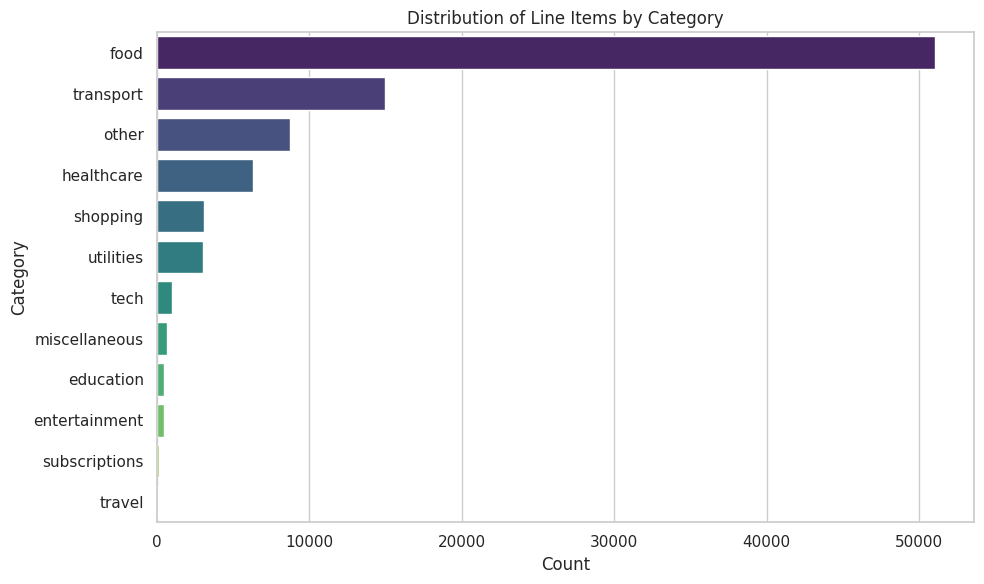

/tmp/ipykernel_1284/685806278.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items.values, y=top_items.index, palette='magma')


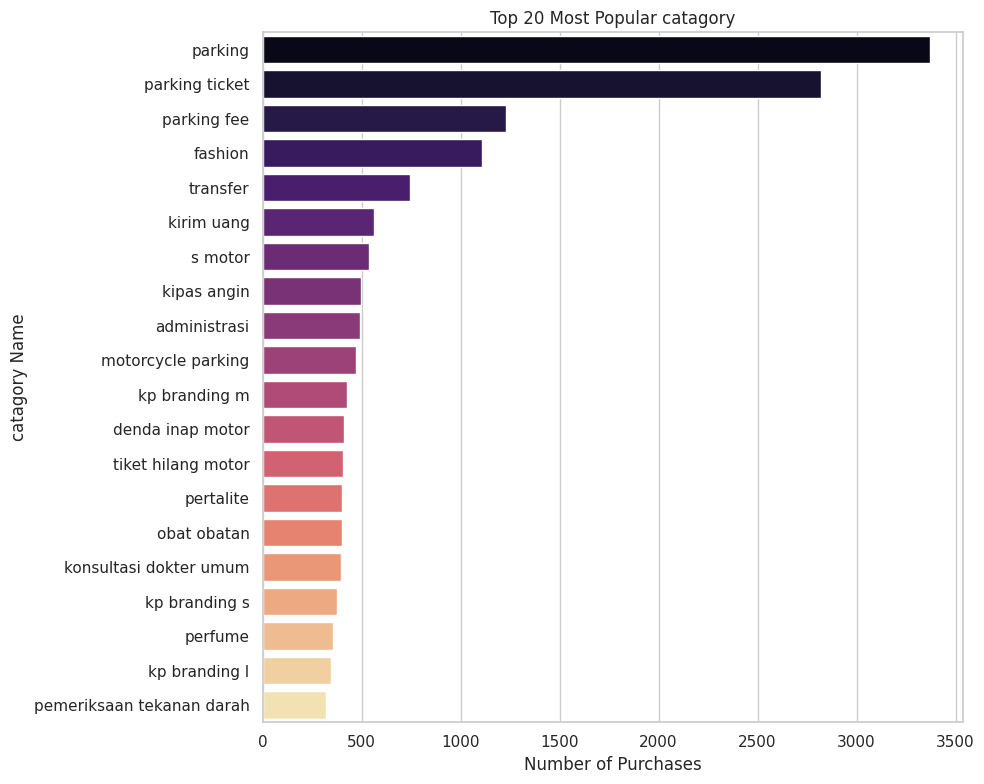

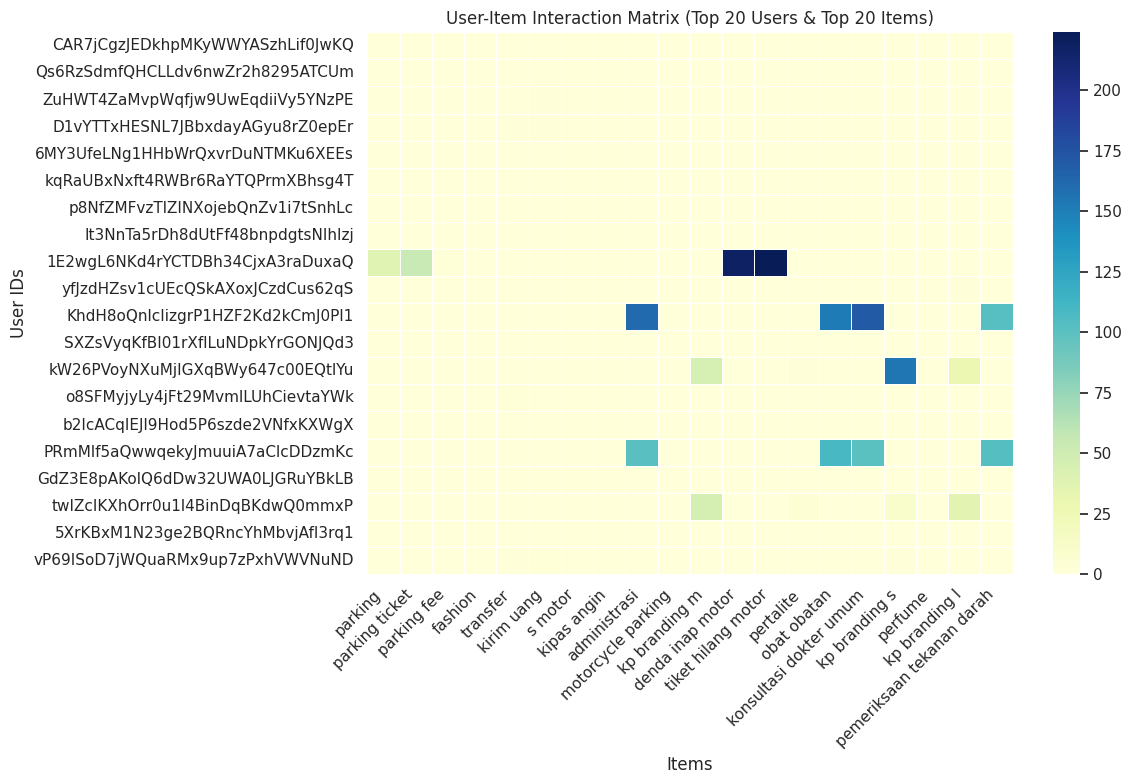

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

# 1. Plot Category Distribution
plt.figure(figsize=(10, 6))
sns.countplot(y='category', data=df, order=df['category'].value_counts().index, palette='viridis')
plt.title('Distribution of Line Items by Category')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# 2. Plot Top 20 Popular Items
plt.figure(figsize=(10, 8))
top_items = df['item'].value_counts().head(20)
sns.barplot(x=top_items.values, y=top_items.index, palette='magma')
plt.title('Top 20 Most Popular catagory')
plt.xlabel('Number of Purchases')
plt.ylabel('catagory Name')
plt.tight_layout()
plt.show()

# 3. Visualize Interaction Matrix Subset (Heatmap)
# We'll take a subset of top users and top items to make the heatmap readable
top_users = df['userId'].value_counts().head(20).index
subset_matrix = engine.interaction_matrix.loc[top_users, top_items.index]

plt.figure(figsize=(12, 8))
sns.heatmap(subset_matrix, cmap='YlGnBu', linewidths=.5)
plt.title('User-Item Interaction Matrix (Top 20 Users & Top 20 Items)')
plt.xlabel('Items')
plt.ylabel('User IDs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [35]:
import os

# 1. Parse and cache User details from the database dump
if 'users_dict' not in globals():
    print("Loading user details from database dump...")

    possible_paths = [
        "boc.backup",
        r"/content/boc.backup",
        "/mnt/c/Users/sanjanab/Desktop/BOC/boc.backup",
        r"c:\Users\sanjanab\Desktop\BOC\boc.backup"
    ]

    dump_path = None
    for path in possible_paths:
        if os.path.exists(path):
            dump_path = path
            break

    users_dict = {}
    if dump_path:
        with open(dump_path, 'r', encoding='utf-8', errors='ignore') as f:
            in_user_table = False
            cols = []
            for line in f:
                if line.startswith("COPY public.\"user\" ("):
                    in_user_table = True
                    col_str = line.split("(")[1].split(")")[0]
                    cols = [c.strip().strip('"') for c in col_str.split(',')]
                    continue
                elif in_user_table and line.startswith(r"\."):
                    break
                elif in_user_table:
                    parts = line.strip('\n').split('\t')
                    if len(parts) == len(cols):
                        row = dict(zip(cols, parts))
                        users_dict[row['id']] = {
                            "name": row.get('name', 'Unknown'),
                            "email": row.get('email', 'Unknown')
                        }
    print(f"Loaded {len(users_dict)} user profiles.")

# 2. Get User Input and Display Recommendations
search_query = input("Enter a User ID, Email, or Name: ").strip()

if not search_query:
    print("No input entered.")
else:
    target_user_id = None
    search_lower = search_query.lower()

    for uid, info in users_dict.items():
        if (search_lower == uid.lower() or
            search_lower == info['email'].lower() or
            search_lower in info['name'].lower()):
            target_user_id = uid
            break

    if not target_user_id:
         print(f"❌ Could not find any user matching '{search_query}'.")
    elif target_user_id not in engine.users:
        user_info = users_dict[target_user_id]
        print(f"⚠️ Found user {user_info['name']}, but they haven't uploaded enough receipts yet to get recommendations.")
    else:
        user_info = users_dict[target_user_id]

        print("\n==================================================")
        print(f"👤 USER PROFILE")
        print(f"   Name:  {user_info['name']}")
        print(f"   Email: {user_info['email']}")
        print("==================================================")
        print("\n⭐ TOP 5 RECOMMENDATIONS ⭐\n")

        recs = engine.get_recommendations(target_user_id, top_n=5)

        if not recs:
            print("No recommendations found.")
        else:
            for i, rec in enumerate(recs, 1):
                # Translate system reasons into plain English
                reason = rec['Reason']
                if "Purchased frequently" in reason:
                    friendly_reason = "The user already buys this frequently, so they will likely need it again."
                elif "Popular among similar" in reason:
                    friendly_reason = "Other users with similar spending habits are buying this."
                elif "Frequently bought with" in reason:
                    item_match = reason.replace("Frequently bought with ", "")
                    friendly_reason = f"People who buy '{item_match}' usually end up buying this too."
                elif "Popular in your favorite" in reason:
                    friendly_reason = "This is a trending item in a category the user already loves."
                else:
                    friendly_reason = reason

                # Convert decimal score to a clean percentage
                confidence = int(rec['Score'] * 100)
                if confidence > 100: confidence = 100
                if confidence < 1: confidence = 1

                print(f"{i}. {rec['Item']}")
                print(f"   💬 Why: {friendly_reason}")
                print(f"   🏷️  Category: {rec['Category'].title()}")
                print(f"   🎯 Confidence: {confidence}%\n")


Enter a User ID, Email, or Name: dingaif45@gmail.com

👤 USER PROFILE
   Name:  Aif
   Email: dingaif45@gmail.com

⭐ TOP 5 RECOMMENDATIONS ⭐

1. Roti O
   💬 Why: The user already buys this frequently, so they will likely need it again.
   🏷️  Category: Food
   🎯 Confidence: 100%

2. Ro Promo Shopee Vip Rp
   💬 Why: The user already buys this frequently, so they will likely need it again.
   🏷️  Category: Food
   🎯 Confidence: 26%

3. Ro Promo Rp
   💬 Why: The user already buys this frequently, so they will likely need it again.
   🏷️  Category: Food
   🎯 Confidence: 19%

4. Kolonoskopi Diagnostik
   💬 Why: People who buy 'Roti O' usually end up buying this too.
   🏷️  Category: Healthcare
   🎯 Confidence: 14%

5. Pemeriksaan Paru
   💬 Why: People who buy 'Roti O' usually end up buying this too.
   🏷️  Category: Healthcare
   🎯 Confidence: 14%

